In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime
import pickle

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config_new import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers_new import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [54]:
show_plot = True


save_fig = True
save_fig_base_dir = "/exp/sbnd/data/users/munjung/xsec/PLOTS/cosmics"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"dent-{today_str}")
if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)


save_content = True
save_content_base_dir = "/exp/sbnd/data/users/munjung/xsec/RESULTS/cosmics"
save_content_dir = path.join(save_content_base_dir, f"dent-{today_str}")
if save_content:
    if not path.exists(save_content_dir):
        makedirs(save_content_dir)
    print("saving nevts in ", save_content_dir)

saving plots in  /exp/sbnd/data/users/munjung/xsec/PLOTS/cosmics/dent-20260515
saving nevts in  /exp/sbnd/data/users/munjung/xsec/RESULTS/cosmics/dent-20260515


In [55]:
perTPC_inset = 10
def perTPC_cut(df):
    in_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    in_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    perTPC_cut = in_TPC1_cut | in_TPC2_cut
    return perTPC_cut

# mc_evt_df_perTPC = mc_evt_df[perTPC_cut(mc_evt_df)]
# data_evt_df_perTPC = data_evt_df[perTPC_cut(data_evt_df)]
# intime_evt_df_perTPC = intime_evt_df[perTPC_cut(intime_evt_df)]

def contTPC1_cut(df):
    cont_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    return cont_TPC1_cut

# mc_evt_df_contTPC1 = mc_evt_df[contTPC1_cut(mc_evt_df)]
# data_evt_df_contTPC1 = data_evt_df[contTPC1_cut(data_evt_df)]
# intime_evt_df_contTPC1 = intime_evt_df[contTPC1_cut(intime_evt_df)]

def contTPC2_cut(df):
    cont_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    return cont_TPC2_cut

# mc_evt_df_contTPC2 = mc_evt_df[contTPC2_cut(mc_evt_df)]
# data_evt_df_contTPC2 = data_evt_df[contTPC2_cut(data_evt_df)]
# intime_evt_df_contTPC2 = intime_evt_df[contTPC2_cut(intime_evt_df)]

def vtxinTPC1_cut(df):
    in_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=0) # & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=2.5) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=2.5)
    return in_TPC1_cut

# mc_evt_df_TPC1 = mc_evt_df[vtxinTPC1_cut(mc_evt_df)]
# data_evt_df_TPC1 = data_evt_df[vtxinTPC1_cut(data_evt_df)]
# intime_evt_df_TPC1 = intime_evt_df[vtxinTPC1_cut(intime_evt_df)]


def vtxinTPC2_cut(df):
    in_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=0) #& InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=2.5) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=2.5)
    return in_TPC2_cut

# mc_evt_df_TPC2 = mc_evt_df[vtxinTPC2_cut(mc_evt_df)]
# data_evt_df_TPC2 = data_evt_df[vtxinTPC2_cut(data_evt_df)]
# intime_evt_df_TPC2 = intime_evt_df[vtxinTPC2_cut(intime_evt_df)]

In [56]:
from pyanalib.split_df_helpers_new import *
pot_label = ""

# filename_data = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/data/BNB/sel_mup-data-1e20.df"
# df_data = load_dfs(filename_data, keys2load=['hdr', 'evt', 'bnbpot'], n_max_concat=300)
# df_data.keys()

# df_dir_mc_nom = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC"
# df_dir_mc_R00 = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_12_112820__sel_mup-mc-EField_R00/merged_perTPC"
# df_dir_mc_R30 = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_12_112945__sel_mup-mc-EField_R30_Short/merged_perTPC"

df_dir_data = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_15_090956__sel_2prong-data-1e20/merged_nominal"
keys2load_data = ['hdr', 'evt', 'bnbpot']
df_data = dfs_from_dir(search_dir=df_dir_data, filename_str="sel_2prong", keys2load=keys2load_data, n_max_concat=300)

df_dir_mc_nom = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/merged_nominal"
df_dir_mc_R00 = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_15_132015__sel_2prong-mc-EField_R00/merged_nominal"
df_dir_mc_R30 = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_15_132115__sel_2prong-mc-EField_R30_Short/merged_nominal"

# ## -- Data
data_evt_df = df_data['evt']
data_hdr_df = df_data['hdr']

# TODO
# Data
data_bnbpot_df = df_data['bnbpot']
# data_tot_pot = data_hdr_df['pot'].sum()
data_tot_pot = data_bnbpot_df["TOR875"].sum()
data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
print("data_tot_pot: %.3e" %(data_tot_pot))
pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_gates = data_hdr_df.nbnbinfo.sum()
print("data tot gates : %.3e" %(data_gates))


# nominal MC
keys2load_data = ['hdr', 'evt']
df_data = dfs_from_dir(search_dir=df_dir_mc_nom, filename_str="sel_2prong", keys2load=keys2load_data, n_max_concat=300)
mc_nom_evt_df = df_data['evt']
mc_nom_hdr_df = df_data['hdr']

# DENT MCs
keys2load_data = ['hdr', 'evt']
df_data = dfs_from_dir(search_dir=df_dir_mc_R00, filename_str="sel_2prong", keys2load=keys2load_data, n_max_concat=999)
mc_R00_evt_df = df_data['evt']
mc_R00_hdr_df = df_data['hdr']

keys2load_data = ['hdr', 'evt']
df_data = dfs_from_dir(search_dir=df_dir_mc_R30, filename_str="sel_2prong", keys2load=keys2load_data, n_max_concat=999)
mc_R30Short_evt_df = df_data['evt']
mc_R30Short_hdr_df = df_data['hdr']


mc_nom_tot_pot = mc_nom_hdr_df['pot'].sum()
mc_nom_pot_scale = data_tot_pot / mc_nom_tot_pot
print("mc_nom_pot_scale: %.3e" %(mc_nom_pot_scale))
mc_nom_evt_df["pot_weight"] = mc_nom_pot_scale * np.ones(len(mc_nom_evt_df))

mc_R00_tot_pot = mc_R00_hdr_df['pot'].sum()
mc_R00_pot_scale = data_tot_pot / mc_R00_tot_pot
print("mc_R00_pot_scale: %.3e" %(mc_R00_pot_scale))
mc_R00_evt_df["pot_weight"] = mc_R00_pot_scale * np.ones(len(mc_R00_evt_df))

mc_R30Short_tot_pot = mc_R30Short_hdr_df['pot'].sum()
mc_R30Short_pot_scale = data_tot_pot / mc_R30Short_tot_pot
print("mc_R30Short_pot_scale: %.3e" %(mc_R30Short_pot_scale))
mc_R30Short_evt_df["pot_weight"] = mc_R30Short_pot_scale * np.ones(len(mc_R30Short_evt_df))

Found 2 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_15_090956__sel_2prong-data-1e20/merged_nominal/2026_05_15_090956__sel_2prong-data-1e20_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_15_090956__sel_2prong-data-1e20/merged_nominal/2026_05_15_090956__sel_2prong-data-1e20_merged_0001.df']


100%|██████████| 2/2 [01:25<00:00, 42.69s/it]


data_tot_pot: 8.372e+19
data tot gates : 1.828e+07
Found 11 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/merged_nominal/2026_05_06_073032__sel_2prong-mc-BNB_cosmics_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/merged_nominal/2026_05_06_073032__sel_2prong-mc-BNB_cosmics_merged_0001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/merged_nominal/2026_05_06_073032__sel_2prong-mc-BNB_cosmics_merged_0002.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/merged_nominal/2026_05_06_073032__sel_2prong-mc-BNB_cosmics_merged_0003.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/merged_nominal/2026_05_06_073032__sel_2prong-mc-BNB_cosmics_merged_0004.df', '/pnfs/sbnd/scratch/users/munjung/cafpy

100%|██████████| 11/11 [01:31<00:00,  8.33s/it]


Found 1 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_15_132015__sel_2prong-mc-EField_R00/merged_nominal/2026_05_15_132015__sel_2prong-mc-EField_R00_merged_0000.df']


100%|██████████| 1/1 [00:02<00:00,  2.96s/it]


Found 1 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_15_132115__sel_2prong-mc-EField_R30_Short/merged_nominal/2026_05_15_132115__sel_2prong-mc-EField_R30_Short_merged_0000.df']


100%|██████████| 1/1 [00:00<00:00,  1.43it/s]

mc_nom_pot_scale: 1.488e-01
mc_R00_pot_scale: 1.381e+01
mc_R30Short_pot_scale: 1.387e+01


In [57]:
## -- Intime Data
intime_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("ad"),
    df_tag="",
    keys2load=['hdr', 'evt'],
    n_max_concat=n_max_concat,
    sub_dir="data",
    sample_dir="OffBeam"
)
intime_hdr_df = intime_dfs['hdr']
intime_evt_df = intime_dfs['evt']


# intime_gates = intime_hdr.noffbeambnb.sum()
intime_gates = intime_hdr_df[intime_hdr_df['first_in_subrun'] == 1]['noffbeambnb'].sum()
f = 0.0753
scale_intime_to_lightdata = (1-f)*data_gates/intime_gates
print("intime data scale: {:.2f}".format(scale_intime_to_lightdata))
intime_evt_df["gates_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))
intime_evt_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))

Reading file with tag aa, mc_n_split: 1
Reading file with tag ab, mc_n_split: 1
Reading file with tag ac, mc_n_split: 1
intime data scale: 0.20


In [58]:
# mc_nom_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_nom_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], mc_nom_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
# mc_nom_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_nom_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], mc_nom_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

# mc_R00_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_R00_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], mc_R00_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
# mc_R00_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_R00_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], mc_R00_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

# mc_R30Short_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_R30Short_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], mc_R30Short_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
# mc_R30Short_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_R30Short_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], mc_R30Short_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

# data_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(data_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], data_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
# data_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(data_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], data_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))


mc_nom_evt_df[('trk1', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_nom_evt_df['trk1', 'pfp', 'trk', 'dir', 'x', '', ''], mc_nom_evt_df['trk1', 'pfp', 'trk', 'dir', 'y', '', '']))
mc_nom_evt_df[('trk2', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_nom_evt_df['trk2', 'pfp', 'trk', 'dir', 'x', '', ''], mc_nom_evt_df['trk2', 'pfp', 'trk', 'dir', 'y', '', '']))

mc_R00_evt_df[('trk1', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_R00_evt_df['trk1', 'pfp', 'trk', 'dir', 'x', '', ''], mc_R00_evt_df['trk1', 'pfp', 'trk', 'dir', 'y', '', '']))
mc_R00_evt_df[('trk2', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_R00_evt_df['trk2', 'pfp', 'trk', 'dir', 'x', '', ''], mc_R00_evt_df['trk2', 'pfp', 'trk', 'dir', 'y', '', '']))

mc_R30Short_evt_df[('trk1', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_R30Short_evt_df['trk1', 'pfp', 'trk', 'dir', 'x', '', ''], mc_R30Short_evt_df['trk1', 'pfp', 'trk', 'dir', 'y', '', '']))
mc_R30Short_evt_df[('trk2', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_R30Short_evt_df['trk2', 'pfp', 'trk', 'dir', 'x', '', ''], mc_R30Short_evt_df['trk2', 'pfp', 'trk', 'dir', 'y', '', '']))

data_evt_df[('trk1', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(data_evt_df['trk1', 'pfp', 'trk', 'dir', 'x', '', ''], data_evt_df['trk1', 'pfp', 'trk', 'dir', 'y', '', '']))
data_evt_df[('trk2', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(data_evt_df['trk2', 'pfp', 'trk', 'dir', 'x', '', ''], data_evt_df['trk2', 'pfp', 'trk', 'dir', 'y', '', '']))


In [59]:
data_evt_df_ = data_evt_df.copy()
mc_nom_evt_df_ = mc_nom_evt_df.copy()
mc_R00_evt_df_ = mc_R00_evt_df.copy()
mc_R30Short_evt_df_ = mc_R30Short_evt_df.copy()

In [60]:
# slice cuts
nu_score_th = 0.45
save_ntrks = 2

# track cuts
trackscore_th = 0.5
vtxdist_th = 1.2

# muon candidate cuts
mu_chi2mu_th = 30
mu_chi2p_th = 100
mu_len_th = 50
qual_th = 0.2

# proton candidate cuts
p_chi2p_th = 90
p_len_th = 0

# track kinematics cuts
mu_Plo_th = 0.22
mu_Phi_th = 1
p_Plo_th = 0.3
p_Phi_th = 1


In [61]:
det = "SBND_nohighyz"
# det = "SBND_perTPC"


data_evt_df = cut_2prong_contained(data_evt_df, det=det)
data_evt_df = cut_2prong_trackscore(data_evt_df, 0.5)
data_evt_df = cut_2prong_vtxdist(data_evt_df, 1.2)

data_evt_df = get_mu_p_candidate(data_evt_df, 
                            mu_chi2mu_th=mu_chi2mu_th, mu_chi2p_th=mu_chi2p_th, mu_len_th=mu_len_th, qual_th=qual_th, 
                            p_chi2mu_th=-1, p_chi2p_th=p_chi2p_th, p_len_th=p_len_th, score_tag="")

mc_nom_evt_df = cut_2prong_contained(mc_nom_evt_df, det=det)
mc_nom_evt_df = cut_2prong_trackscore(mc_nom_evt_df, 0.5)
mc_nom_evt_df = cut_2prong_vtxdist(mc_nom_evt_df, 1.2)
mc_nom_evt_df = get_mu_p_candidate(mc_nom_evt_df, 
                            mu_chi2mu_th=mu_chi2mu_th, mu_chi2p_th=mu_chi2p_th, mu_len_th=mu_len_th, qual_th=qual_th, 
                            p_chi2mu_th=-1, p_chi2p_th=p_chi2p_th, p_len_th=p_len_th, score_tag="")

mc_R00_evt_df = cut_2prong_contained(mc_R00_evt_df, det=det)
mc_R00_evt_df = cut_2prong_trackscore(mc_R00_evt_df, 0.5)
mc_R00_evt_df = cut_2prong_vtxdist(mc_R00_evt_df, 1.2)
mc_R00_evt_df = get_mu_p_candidate(mc_R00_evt_df, 
                            mu_chi2mu_th=mu_chi2mu_th, mu_chi2p_th=mu_chi2p_th, mu_len_th=mu_len_th, qual_th=qual_th, 
                            p_chi2mu_th=-1, p_chi2p_th=p_chi2p_th, p_len_th=p_len_th, score_tag="")

mc_R30Short_evt_df = cut_2prong_contained(mc_R30Short_evt_df, det=det)
mc_R30Short_evt_df = cut_2prong_trackscore(mc_R30Short_evt_df, 0.5)
mc_R30Short_evt_df = cut_2prong_vtxdist(mc_R30Short_evt_df, 1.2)
mc_R30Short_evt_df = get_mu_p_candidate(mc_R30Short_evt_df, 
                            mu_chi2mu_th=mu_chi2mu_th, mu_chi2p_th=mu_chi2p_th, mu_len_th=mu_len_th, qual_th=qual_th, 
                            p_chi2mu_th=-1, p_chi2p_th=p_chi2p_th, p_len_th=p_len_th, score_tag="")

In [62]:
data_evt_df = cut_has_mu(data_evt_df)
data_evt_df = cut_mu_kinematics(data_evt_df, mu_Plo_th=mu_Plo_th, mu_Phi_th=mu_Phi_th)

mc_nom_evt_df = cut_has_mu(mc_nom_evt_df)
mc_nom_evt_df = cut_mu_kinematics(mc_nom_evt_df, mu_Plo_th=mu_Plo_th, mu_Phi_th=mu_Phi_th)

mc_R00_evt_df = cut_has_mu(mc_R00_evt_df)
mc_R00_evt_df = cut_mu_kinematics(mc_R00_evt_df, mu_Plo_th=mu_Plo_th, mu_Phi_th=mu_Phi_th)

mc_R30Short_evt_df = cut_has_mu(mc_R30Short_evt_df)
mc_R30Short_evt_df = cut_mu_kinematics(mc_R30Short_evt_df, mu_Plo_th=mu_Plo_th, mu_Phi_th=mu_Phi_th)


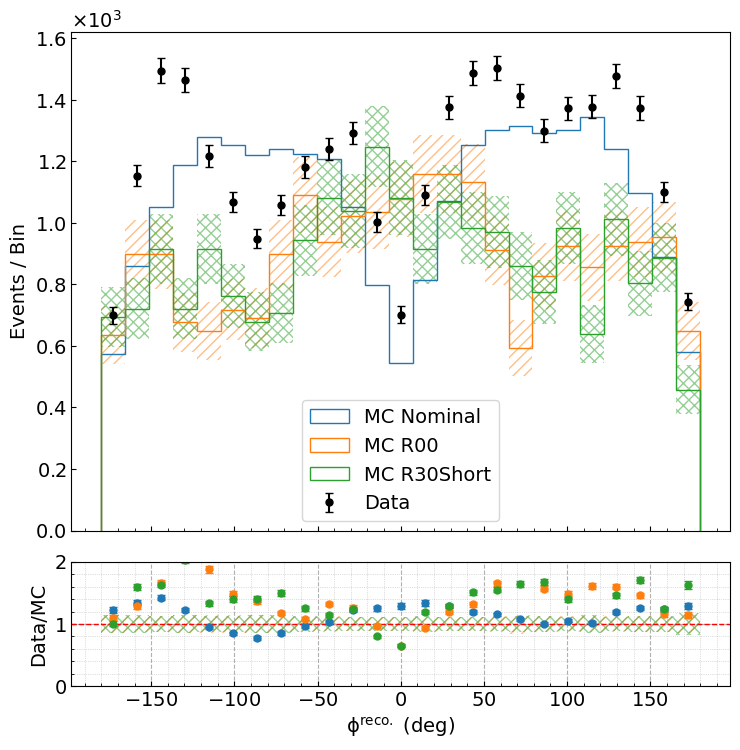

In [63]:
var_configs = [
#     VariableConfig.muon_momentum(),
    # VariableConfig.muon_direction_x(),
    # VariableConfig.muon_direction_y(),
#     VariableConfig.muon_direction_phi(),
    VariableConfig.trk1_direction_phi(),
    # VariableConfig.proton_direction_x(),
    # VariableConfig.proton_direction_y(),
    # VariableConfig.proton_direction_phi(),
#     VariableConfig.vertex_x(),
#     VariableConfig.vertex_y(),
#     VariableConfig.vertex_z(),
#     VariableConfig.muon_end_x(),
    # VariableConfig.muon_end_y(),
    # VariableConfig.muon_end_z(),
    ]

for var_config in var_configs:

        fig, axs = plt.subplots(2, 1, figsize=(8.5, 8.5), 
                                sharex=True, gridspec_kw={'height_ratios': [4, 1]})
        ax, ax_r = axs[0], axs[1]
        fig.subplots_adjust(hspace=0.1)

        ax.set_ylabel("Events / Bin")

        ax_r.axhline(1.0, color='red', linestyle='--', linewidth=1)
        # ax_r.set_ylim(0.5, 1.5)
        ax_r.set_ylim(0., 2.)
        ax_r.set_xlabel(var_config.var_labels[1])
        ax_r.set_ylabel("Data/MC")
        ax_r.grid(True)
        ax_r.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
        ax_r.minorticks_on()

        # files (POT-weighted yields; MC stat err from unweighted counts × pot scale)
        vardf_mc_nom, _   = get_clipped_evts(mc_nom_evt_df, var_config.var_evt_reco_col, var_config.bins)
        total_mc_nom, _ = np.histogram(vardf_mc_nom, bins=var_config.bins, weights=mc_nom_evt_df.pot_weight)
        raw_mc_nom, _ = np.histogram(vardf_mc_nom, bins=var_config.bins)
        mc_nom_pot_scale = mc_nom_evt_df.pot_weight.unique()[0]
        sum_mc_nom = np.sum(total_mc_nom)
        mc_nom_stat = mc_nom_pot_scale * np.sqrt(np.maximum(raw_mc_nom, 0.))

        vardf_mc_R00, _   = get_clipped_evts(mc_R00_evt_df, var_config.var_evt_reco_col, var_config.bins)
        total_mc_R00, _ = np.histogram(vardf_mc_R00, bins=var_config.bins, weights=mc_R00_evt_df.pot_weight)
        raw_mc_R00, _ = np.histogram(vardf_mc_R00, bins=var_config.bins)
        mc_R00_pot_scale = mc_R00_evt_df.pot_weight.unique()[0]
        sum_mc_R00 = np.sum(total_mc_R00)
        mc_R00_stat = mc_R00_pot_scale * np.sqrt(np.maximum(raw_mc_R00, 0.))

        vardf_mc_R30Short, _   = get_clipped_evts(mc_R30Short_evt_df, var_config.var_evt_reco_col, var_config.bins)
        total_mc_R30Short, _ = np.histogram(vardf_mc_R30Short, bins=var_config.bins, weights=mc_R30Short_evt_df.pot_weight)
        raw_mc_R30Short, _ = np.histogram(vardf_mc_R30Short, bins=var_config.bins)
        mc_R30Short_pot_scale = mc_R30Short_evt_df.pot_weight.unique()[0]
        sum_mc_R30Short = np.sum(total_mc_R30Short)
        mc_R30Short_stat = mc_R30Short_pot_scale * np.sqrt(np.maximum(raw_mc_R30Short, 0.))

        vardf_data, _   = get_clipped_evts(data_evt_df, var_config.var_evt_reco_col, var_config.bins)
        total_data, _ = np.histogram(vardf_data, bins=var_config.bins, weights=data_evt_df.pot_weight)
        sum_data = np.sum(total_data)
        data_eylow, data_eyhigh = return_data_stat_err(total_data)

        # ratios
        data_ratio_nom = total_data / total_mc_nom
        data_ratio_nom_eylow = data_eylow / total_mc_nom
        data_ratio_nom_eyhigh = data_eyhigh / total_mc_nom
        data_ratio_nom = np.nan_to_num(data_ratio_nom, nan=-999.)
        data_ratio_nom_eylow = np.nan_to_num(data_ratio_nom_eylow, nan=0.)
        data_ratio_nom_eyhigh = np.nan_to_num(data_ratio_nom_eyhigh, nan=0.)

        data_ratio_R00 = total_data / total_mc_R00
        data_ratio_R00_eylow = data_eylow / total_mc_R00
        data_ratio_R00_eyhigh = data_eyhigh / total_mc_R00
        data_ratio_R00 = np.nan_to_num(data_ratio_R00, nan=-999.)
        data_ratio_R00_eylow = np.nan_to_num(data_ratio_R00_eylow, nan=0.)
        data_ratio_R00_eyhigh = np.nan_to_num(data_ratio_R00_eyhigh, nan=0.)

        data_ratio_R30Short = total_data / total_mc_R30Short
        data_ratio_R30Short_eylow = data_eylow / total_mc_R30Short
        data_ratio_R30Short_eyhigh = data_eyhigh / total_mc_R30Short
        data_ratio_R30Short = np.nan_to_num(data_ratio_R30Short, nan=-999.)
        data_ratio_R30Short_eylow = np.nan_to_num(data_ratio_R30Short_eylow, nan=0.)
        data_ratio_R30Short_eyhigh = np.nan_to_num(data_ratio_R30Short_eyhigh, nan=0.)


        # plot
        ax.hist(var_config.bin_centers,
                bins=var_config.bins,
                weights=total_mc_nom,
                histtype='step',
                label='MC Nominal',
                color="C0")

        ax.hist(var_config.bin_centers,
                bins=var_config.bins,
                weights=total_mc_R00,
                histtype='step',
                label='MC R00',
                color="C1")
        _bw = np.diff(var_config.bins)
        ax.bar(var_config.bin_centers, 2 * mc_R00_stat, width=_bw,
               bottom=total_mc_R00 - mc_R00_stat,
               facecolor='none', edgecolor='C1', hatch='///', linewidth=0.0, alpha=0.5)

        ax.hist(var_config.bin_centers,
                bins=var_config.bins,
                weights=total_mc_R30Short,
                histtype='step',
                label='MC R30Short',
                color="C2")
        ax.bar(var_config.bin_centers, 2 * mc_R30Short_stat, width=_bw,
               bottom=total_mc_R30Short - mc_R30Short_stat,
               facecolor='none', edgecolor='C2', hatch='xxx', linewidth=0.0, alpha=0.5)

        ax.errorbar(var_config.bin_centers, 
                total_data, 
                yerr=np.vstack((data_eylow, data_eyhigh)),
                color='black', 
                fmt='o', markersize=5, capsize=3, linewidth=1.5,
                label='Data')

        ax.legend()

        # fractional MC stat unc bands around y=1 (mirror upper-panel hatch)
        with np.errstate(divide='ignore', invalid='ignore'):
            mc_R00_frac = np.where(total_mc_R00 != 0, mc_R00_stat / total_mc_R00, 0.0)
            mc_R30Short_frac = np.where(total_mc_R30Short != 0, mc_R30Short_stat / total_mc_R30Short, 0.0)
        mc_R00_frac = np.nan_to_num(mc_R00_frac, nan=0.)
        mc_R30Short_frac = np.nan_to_num(mc_R30Short_frac, nan=0.)

        ax_r.bar(var_config.bin_centers, 2 * mc_R00_frac, width=_bw,
                 bottom=1.0 - mc_R00_frac,
                 facecolor='none', edgecolor='C1', hatch='///', linewidth=0.0, alpha=0.5, zorder=1)
        ax_r.bar(var_config.bin_centers, 2 * mc_R30Short_frac, width=_bw,
                 bottom=1.0 - mc_R30Short_frac,
                 facecolor='none', edgecolor='C2', hatch='xxx', linewidth=0.0, alpha=0.5, zorder=1)

        ax_r.errorbar(var_config.bin_centers, data_ratio_nom, 
                        yerr=np.vstack((data_ratio_nom_eylow, data_ratio_nom_eyhigh)),
                        fmt='o', color='C0',
                        markersize=5, capsize=3, linewidth=1.5)

        ax_r.errorbar(var_config.bin_centers, data_ratio_R00, 
                        yerr=np.vstack((data_ratio_R00_eylow, data_ratio_R00_eyhigh)),
                        fmt='o', color='C1',
                        markersize=5, capsize=3, linewidth=1.5)

        ax_r.errorbar(var_config.bin_centers, data_ratio_R30Short, 
                        yerr=np.vstack((data_ratio_R30Short_eylow, data_ratio_R30Short_eyhigh)),
                        fmt='o', color='C2',
                        markersize=5, capsize=3, linewidth=1.5)



        plt.show();

In [45]:
perTPC_inset = 10
def perTPC_cut(df):
    in_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.trk1.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.trk2.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    in_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.trk1.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.trk2.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    return in_TPC1_cut | in_TPC2_cut

In [46]:
data_evt_df = data_evt_df[perTPC_cut(data_evt_df)]
mc_nom_evt_df = mc_nom_evt_df[perTPC_cut(mc_nom_evt_df)]
mc_R00_evt_df = mc_R00_evt_df[perTPC_cut(mc_R00_evt_df)]
mc_R30Short_evt_df = mc_R30Short_evt_df[perTPC_cut(mc_R30Short_evt_df)]


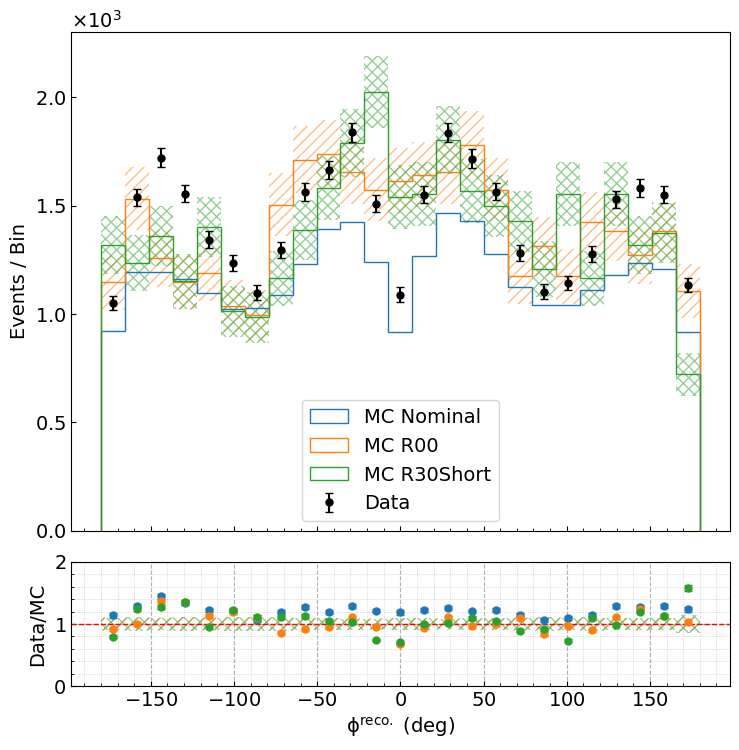

In [47]:
var_configs = [
#     VariableConfig.muon_momentum(),
    # VariableConfig.muon_direction_x(),
    # VariableConfig.muon_direction_y(),
#     VariableConfig.muon_direction_phi(),
    VariableConfig.trk1_direction_phi(),
    # VariableConfig.proton_direction_x(),
    # VariableConfig.proton_direction_y(),
    # VariableConfig.proton_direction_phi(),
#     VariableConfig.vertex_x(),
#     VariableConfig.vertex_y(),
#     VariableConfig.vertex_z(),
#     VariableConfig.muon_end_x(),
    # VariableConfig.muon_end_y(),
    # VariableConfig.muon_end_z(),
    ]

for var_config in var_configs:

        fig, axs = plt.subplots(2, 1, figsize=(8.5, 8.5), 
                                sharex=True, gridspec_kw={'height_ratios': [4, 1]})
        ax, ax_r = axs[0], axs[1]
        fig.subplots_adjust(hspace=0.1)

        ax.set_ylabel("Events / Bin")

        ax_r.axhline(1.0, color='red', linestyle='--', linewidth=1)
        # ax_r.set_ylim(0.5, 1.5)
        ax_r.set_ylim(0., 2.)
        ax_r.set_xlabel(var_config.var_labels[1])
        ax_r.set_ylabel("Data/MC")
        ax_r.grid(True)
        ax_r.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
        ax_r.minorticks_on()

        # files (POT-weighted yields; MC stat err from unweighted counts × pot scale)
        vardf_mc_nom, _   = get_clipped_evts(mc_nom_evt_df, var_config.var_evt_reco_col, var_config.bins)
        total_mc_nom, _ = np.histogram(vardf_mc_nom, bins=var_config.bins, weights=mc_nom_evt_df.pot_weight)
        raw_mc_nom, _ = np.histogram(vardf_mc_nom, bins=var_config.bins)
        mc_nom_pot_scale = mc_nom_evt_df.pot_weight.unique()[0]
        sum_mc_nom = np.sum(total_mc_nom)
        mc_nom_stat = mc_nom_pot_scale * np.sqrt(np.maximum(raw_mc_nom, 0.))

        vardf_mc_R00, _   = get_clipped_evts(mc_R00_evt_df, var_config.var_evt_reco_col, var_config.bins)
        total_mc_R00, _ = np.histogram(vardf_mc_R00, bins=var_config.bins, weights=mc_R00_evt_df.pot_weight)
        raw_mc_R00, _ = np.histogram(vardf_mc_R00, bins=var_config.bins)
        mc_R00_pot_scale = mc_R00_evt_df.pot_weight.unique()[0]
        sum_mc_R00 = np.sum(total_mc_R00)
        mc_R00_stat = mc_R00_pot_scale * np.sqrt(np.maximum(raw_mc_R00, 0.))

        vardf_mc_R30Short, _   = get_clipped_evts(mc_R30Short_evt_df, var_config.var_evt_reco_col, var_config.bins)
        total_mc_R30Short, _ = np.histogram(vardf_mc_R30Short, bins=var_config.bins, weights=mc_R30Short_evt_df.pot_weight)
        raw_mc_R30Short, _ = np.histogram(vardf_mc_R30Short, bins=var_config.bins)
        mc_R30Short_pot_scale = mc_R30Short_evt_df.pot_weight.unique()[0]
        sum_mc_R30Short = np.sum(total_mc_R30Short)
        mc_R30Short_stat = mc_R30Short_pot_scale * np.sqrt(np.maximum(raw_mc_R30Short, 0.))

        vardf_data, _   = get_clipped_evts(data_evt_df, var_config.var_evt_reco_col, var_config.bins)
        total_data, _ = np.histogram(vardf_data, bins=var_config.bins, weights=data_evt_df.pot_weight)
        sum_data = np.sum(total_data)
        data_eylow, data_eyhigh = return_data_stat_err(total_data)

        # ratios
        data_ratio_nom = total_data / total_mc_nom
        data_ratio_nom_eylow = data_eylow / total_mc_nom
        data_ratio_nom_eyhigh = data_eyhigh / total_mc_nom
        data_ratio_nom = np.nan_to_num(data_ratio_nom, nan=-999.)
        data_ratio_nom_eylow = np.nan_to_num(data_ratio_nom_eylow, nan=0.)
        data_ratio_nom_eyhigh = np.nan_to_num(data_ratio_nom_eyhigh, nan=0.)

        data_ratio_R00 = total_data / total_mc_R00
        data_ratio_R00_eylow = data_eylow / total_mc_R00
        data_ratio_R00_eyhigh = data_eyhigh / total_mc_R00
        data_ratio_R00 = np.nan_to_num(data_ratio_R00, nan=-999.)
        data_ratio_R00_eylow = np.nan_to_num(data_ratio_R00_eylow, nan=0.)
        data_ratio_R00_eyhigh = np.nan_to_num(data_ratio_R00_eyhigh, nan=0.)

        data_ratio_R30Short = total_data / total_mc_R30Short
        data_ratio_R30Short_eylow = data_eylow / total_mc_R30Short
        data_ratio_R30Short_eyhigh = data_eyhigh / total_mc_R30Short
        data_ratio_R30Short = np.nan_to_num(data_ratio_R30Short, nan=-999.)
        data_ratio_R30Short_eylow = np.nan_to_num(data_ratio_R30Short_eylow, nan=0.)
        data_ratio_R30Short_eyhigh = np.nan_to_num(data_ratio_R30Short_eyhigh, nan=0.)


        # plot
        ax.hist(var_config.bin_centers,
                bins=var_config.bins,
                weights=total_mc_nom,
                histtype='step',
                label='MC Nominal',
                color="C0")

        ax.hist(var_config.bin_centers,
                bins=var_config.bins,
                weights=total_mc_R00,
                histtype='step',
                label='MC R00',
                color="C1")
        _bw = np.diff(var_config.bins)
        ax.bar(var_config.bin_centers, 2 * mc_R00_stat, width=_bw,
               bottom=total_mc_R00 - mc_R00_stat,
               facecolor='none', edgecolor='C1', hatch='///', linewidth=0.0, alpha=0.5)

        ax.hist(var_config.bin_centers,
                bins=var_config.bins,
                weights=total_mc_R30Short,
                histtype='step',
                label='MC R30Short',
                color="C2")
        ax.bar(var_config.bin_centers, 2 * mc_R30Short_stat, width=_bw,
               bottom=total_mc_R30Short - mc_R30Short_stat,
               facecolor='none', edgecolor='C2', hatch='xxx', linewidth=0.0, alpha=0.5)

        ax.errorbar(var_config.bin_centers, 
                total_data, 
                yerr=np.vstack((data_eylow, data_eyhigh)),
                color='black', 
                fmt='o', markersize=5, capsize=3, linewidth=1.5,
                label='Data')

        ax.legend()

        # fractional MC stat unc bands around y=1 (mirror upper-panel hatch)
        with np.errstate(divide='ignore', invalid='ignore'):
            mc_R00_frac = np.where(total_mc_R00 != 0, mc_R00_stat / total_mc_R00, 0.0)
            mc_R30Short_frac = np.where(total_mc_R30Short != 0, mc_R30Short_stat / total_mc_R30Short, 0.0)
        mc_R00_frac = np.nan_to_num(mc_R00_frac, nan=0.)
        mc_R30Short_frac = np.nan_to_num(mc_R30Short_frac, nan=0.)

        ax_r.bar(var_config.bin_centers, 2 * mc_R00_frac, width=_bw,
                 bottom=1.0 - mc_R00_frac,
                 facecolor='none', edgecolor='C1', hatch='///', linewidth=0.0, alpha=0.5, zorder=1)
        ax_r.bar(var_config.bin_centers, 2 * mc_R30Short_frac, width=_bw,
                 bottom=1.0 - mc_R30Short_frac,
                 facecolor='none', edgecolor='C2', hatch='xxx', linewidth=0.0, alpha=0.5, zorder=1)

        ax_r.errorbar(var_config.bin_centers, data_ratio_nom, 
                        yerr=np.vstack((data_ratio_nom_eylow, data_ratio_nom_eyhigh)),
                        fmt='o', color='C0',
                        markersize=5, capsize=3, linewidth=1.5)

        ax_r.errorbar(var_config.bin_centers, data_ratio_R00, 
                        yerr=np.vstack((data_ratio_R00_eylow, data_ratio_R00_eyhigh)),
                        fmt='o', color='C1',
                        markersize=5, capsize=3, linewidth=1.5)

        ax_r.errorbar(var_config.bin_centers, data_ratio_R30Short, 
                        yerr=np.vstack((data_ratio_R30Short_eylow, data_ratio_R30Short_eyhigh)),
                        fmt='o', color='C2',
                        markersize=5, capsize=3, linewidth=1.5)



        plt.show();